# Hackaton

## Equipo 5 - Planetas análogos

* Cristóbal Castro Riquelme
* Vanessa Meza
* Antonia Morales



In [1]:
#Importamos las librerías a usar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
#Cargamos los datos

df = pd.read_csv("hwc.csv")
df.set_index("P_NAME", inplace=True)
#Devolvemos los primeros cinco valores de la tabla para tener una visión general
df.head()

,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,P_RADIUS,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
P_NAME,,,,,,,,,,,,,,,,,,,,,
OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,13.90,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,2.90,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,2.11,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,3.52,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,2.07,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [3]:
#Limpiamos los datos de interés
clean_df = df[["P_MASS", "P_DENSITY", "P_RADIUS", "P_FLUX", "P_ESI", "P_HABITABLE", "P_TEMP_SURF"]].dropna()
clean_mass = clean_df["P_MASS"]
clean_density = clean_df["P_DENSITY"]
clean_radius = clean_df["P_RADIUS"]
clean_flux = clean_df["P_FLUX"]
clean_esi = clean_df["P_ESI"]
clean_temp = clean_df["P_TEMP_SURF"]

clean_df

,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
Kepler-829 b,5.100,0.542904,2.110,238.528680,0.254763,0,1130.60440
Kepler-477 b,4.940,0.556950,2.070,51.163853,0.276721,0,769.42507
TOI-238 b,3.400,1.233772,1.402,766.125920,0.284877,0,1504.26870
TOI-1470 b,7.320,0.706548,2.180,48.505343,0.272496,0,746.01801
HD 86226 c,7.250,0.719410,2.160,492.983910,0.249443,0,1354.17430
...,...,...,...,...,...,...,...
Kepler-1834 b,2.730,0.879016,1.459,107.655610,0.293471,0,926.69044
Kepler-1869 c,0.330,0.814364,0.740,1136.799700,0.286272,0,1670.50010
Kepler-290 d,0.566,0.889859,0.860,1093.852000,0.292181,0,1654.49390


In [4]:
#Nuestra intención inicial era filtrar los datos para no considerar supertierras y poder manejar datos de nuestro interés,
#sin embargo, por falta de tiempo hemos terminado utilizando el DataFrame limpio.
selection_mass = clean_df[clean_df["P_MASS"] <= 5]
selection_esi = selection_mass[selection_mass["P_ESI"] >= 0.5]
selection_esi


,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
GJ 357 c,3.40,0.743284,1.660,4.278981,0.527043,0,413.77153
L 98-59 d,2.31,0.585653,1.580,4.402496,0.527143,0,416.72568
TOI-270 d,4.78,0.492556,2.133,3.735527,0.518092,0,399.88037
L 98-59 e,3.06,0.806023,1.560,2.210797,0.691733,0,349.71904
GJ 1132 c,2.64,0.902809,1.430,2.005501,0.732382,0,337.56210
...,...,...,...,...,...,...,...
Ross 508 b,4.00,0.652690,1.830,1.320491,0.770771,2,301.85915
Wolf 1069 b,1.26,1.000229,1.080,0.652021,0.848593,1,258.51806
Kepler-1126 b,3.64,0.703013,1.730,4.676722,0.504522,0,423.06871


In [5]:
#La cantidad de datos con la que teníamos la intención de trabajar
len (selection_esi[selection_esi["P_HABITABLE"] > 0])

40

### Figuras
Realizamos tres scatter plots comparativos según distintos parámetros y como se relacionan según los valores de la Tierra.

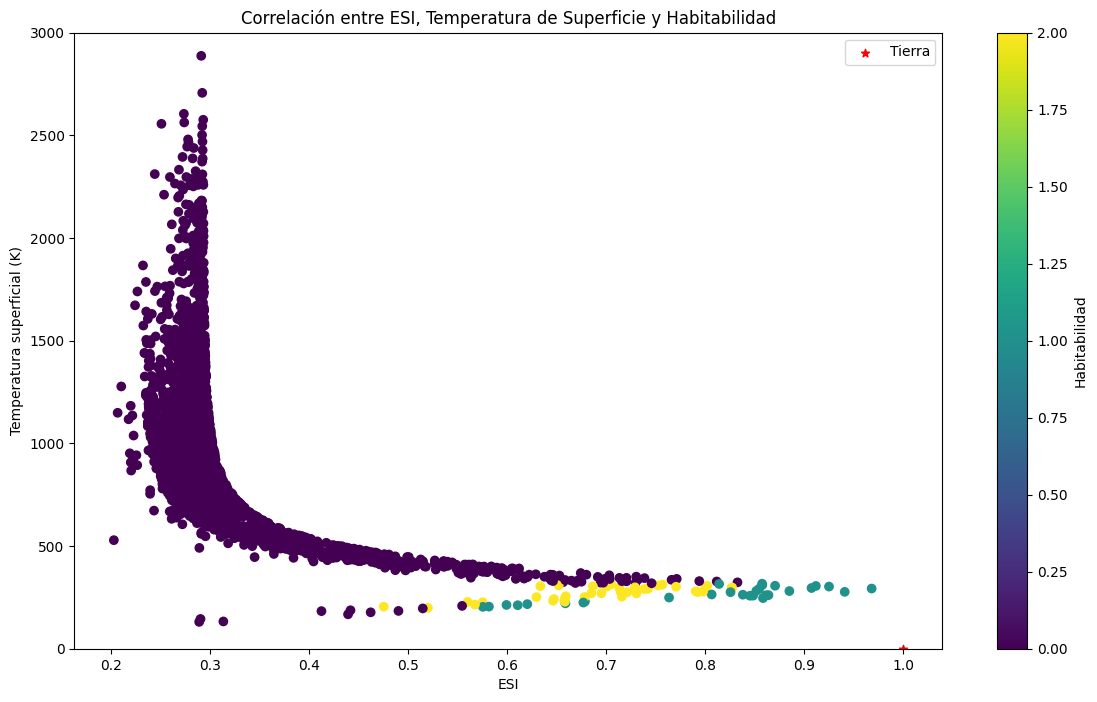

In [6]:
#Gráfico donde comparamos los planetas según ESI y Temperatura Superficial, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_TEMP_SURF"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.scatter(1, 1, color="red", marker="*", label="Tierra")
plt.xlabel("ESI")
plt.ylabel("Temperatura superficial (K)")
plt.title("Correlación entre ESI, Temperatura de Superficie y Habitabilidad")
plt.legend()
plt.ylim(0, 3000)
plt.show()

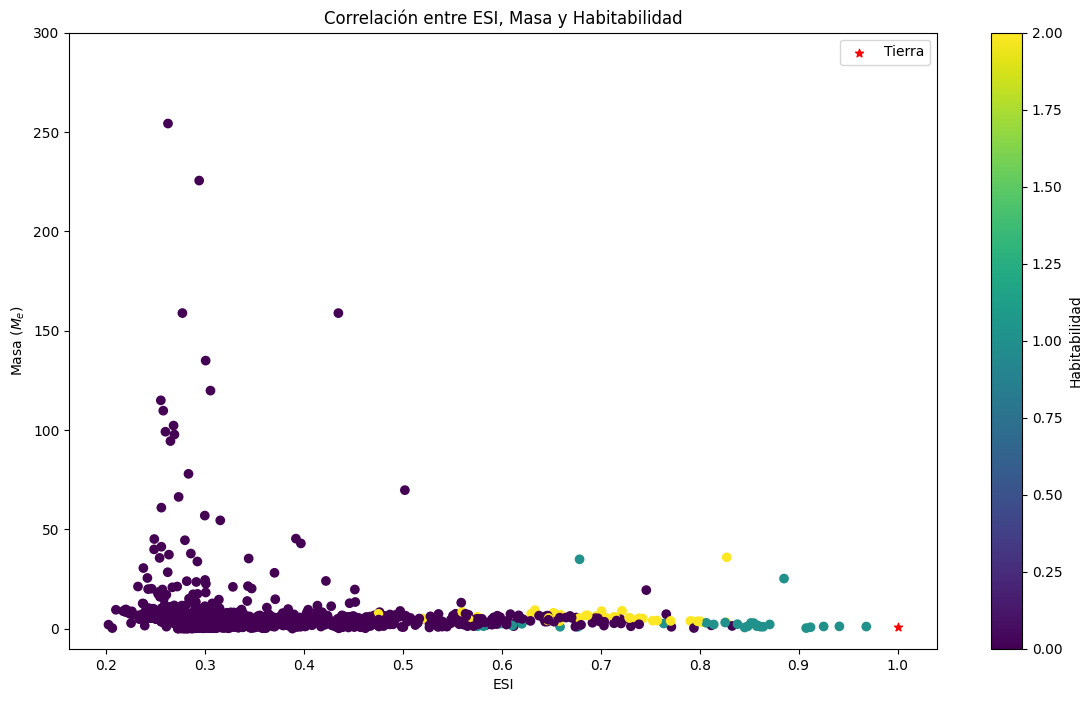

In [7]:
#Gráfico donde comparamos los planetas según ESI y Masa, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_MASS"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.scatter(1, 1, color="red", marker="*", label="Tierra")
plt.xlabel("ESI")
plt.ylabel(r"Masa $(M_e)$")
plt.title("Correlación entre ESI, Masa y Habitabilidad")
plt.legend()
plt.ylim(-10, 300)
plt.show()

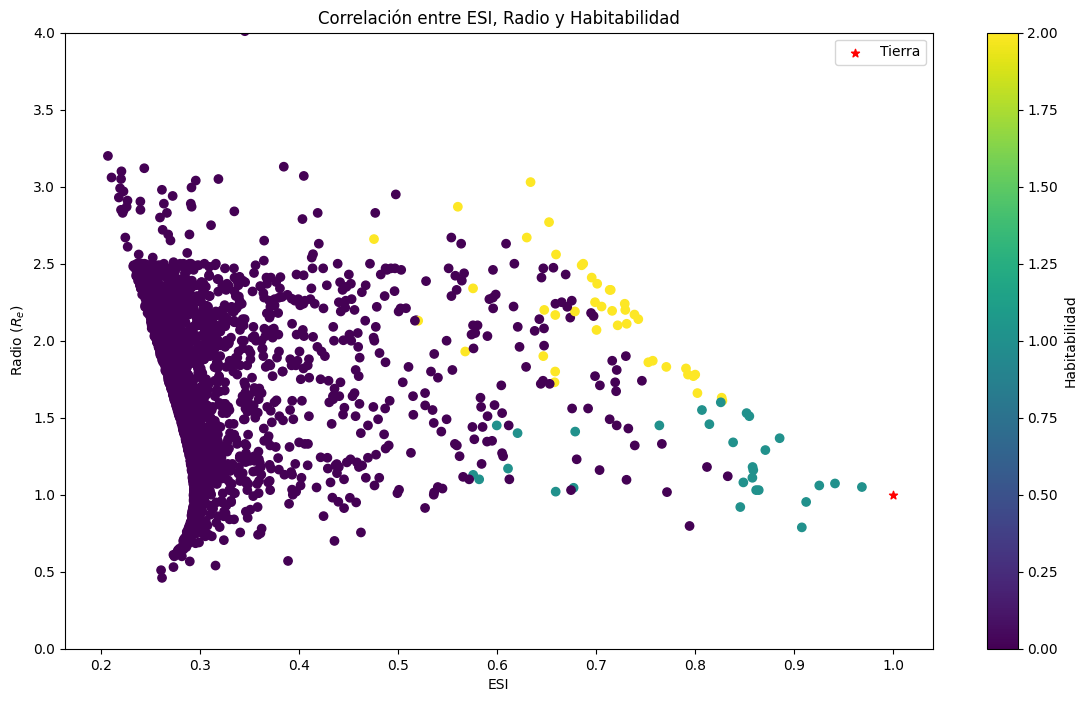

In [8]:
#Gráfico donde comparamos los planetas según ESI y Radio, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_RADIUS"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.scatter(1, 1, color="red", marker="*", label="Tierra")
plt.xlabel("ESI")
plt.ylabel(r"Radio $(R_e)$")
plt.title("Correlación entre ESI, Radio y Habitabilidad")
plt.legend()
plt.ylim(0,4)
plt.show()

## Tres candidatos elegidos
Finalmente, ordenamos los valores según mayor ESI a menor y escogemos los primeros tres, ya que nos concentramos únicamente en relaciones físicas muy similares a la Tierra, más no implica que sean automáticamente apropiados para la habitabilidad.
Es por esto que consideramos que la selección de planetas mediante este método es ineficiente y requiere de más métodos acompañantes.

In [9]:
sort_df = clean_df.sort_values("P_ESI", ascending = False)
sort_df.head(3)

,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
Teegarden's Star b,1.16,1.002052,1.050,1.077943,0.968362,1,293.09014
TOI-700 d,1.25,1.011838,1.073,0.859827,0.941176,1,276.93926
Kepler-1649 c,1.20,1.007543,1.060,1.226057,0.925298,1,302.72840
